# Three-Model Ensemble V2 — Full Walk-Forward Performance Evaluation

## Contents

| Section | Description |
|---------|-------------|
| 1. Imports, Paths & Best-Params Load | Load hyperparameters saved by the training notebook |
| 2. Data Load & Feature Engineering | Load raw data, compute derived features |
| 3. Fold Definitions | 13 quarterly walk-forward folds |
| 4. Evaluation Helpers | Stride-offset metrics, majority vote logic |
| 5. Full Walk-Forward: Individual Models | Per-fold fit and predict for each sub-model |
| 6. Ensemble Predictions | Hard majority vote (primary) and soft-prob average (diagnostic) |
| 7. Performance Summary | Directional accuracy and call rate per fold and in aggregate |
| 7b. Per-Fold Confusion Matrix | Actual vs predicted class counts per fold (hard majority vote) |
| 8. SHAP — Out-of-Sample Test Data | Pooled beeswarm plots for +1 and −1 classes, all models |
| 9. Walk-Forward SHAP Importance | Mean \|SHAP\| per fold (feature stability over time) |
| 10. Per-Fold SHAP Breakdown | Top-3 features per model, per class, per fold |
| 11. Fold 1 & 8 — SHAP Beeswarm Plots | Per-direction beeswarm for the two weakest folds |
| 12. Model Governance | Per-fold and aggregate comparison vs majority-class and momentum baselines; 95% Wald CI |

**Feature set (V2 final)**

| Model | Count | Features |
|-------|-------|----------|
| Price | 6 | `td_return_5d`, `td_return_20d`, `td_vs_xfn_5d`, `td_vs_xfn_20d`, `td_dist_52w_high_v2`, `td_volatility_20d` |
| Transcript | 10 | Exec tone, analyst Q&A sentiment, framing gap, topic shares/sentiments (guidance, AML, credit quality), `days_since_call` |
| News | 5 | `news_sent_mean_7d/30d`, `news_count_7d/30d`, `days_since_last_news` |

*For documentation, see `docs/model_card.md`, `docs/feature_engineering.md`, and `docs/model_explainability.md`.*


## 1. Imports, Paths & Best-Params Load

In [1]:
import sys
import warnings
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap
import xgboost as xgb
from sklearn.metrics import roc_auc_score
from IPython.display import display

warnings.filterwarnings('ignore')

NOTEBOOK_DIR = Path('').resolve()          # final_model/notebooks/ when run via nbconvert or Jupyter
FINAL_MODEL_DIR = NOTEBOOK_DIR.parent     # final_model/
ROOT = FINAL_MODEL_DIR.parents[1]         # project root (step3_predictive_model -> project root)
EXP_PARENT = ROOT / 'step3_predictive_model/model_experiments_archive'
STEP3_DIR = ROOT / 'step3_predictive_model'
for p in [str(ROOT), str(EXP_PARENT), str(STEP3_DIR)]:
    if p not in sys.path:
        sys.path.insert(0, p)

ARTIFACT_DIR = FINAL_MODEL_DIR / 'artifacts'

param_files = sorted(ARTIFACT_DIR.glob('best_params_*.json'))
assert param_files, 'No best_params_*.json found — run xgb_ensemble_v2_training.ipynb first'
params_path = param_files[-1]
with open(params_path) as f:
    saved = json.load(f)

TARGET            = saved['target']
THRESHOLD         = saved['threshold']
LABEL_MAP         = {-1: 0, 0: 1, 1: 2}
INV_MAP           = {0: -1, 1: 0, 2: 1}
TRAIN_WINDOW_DAYS = saved['train_window_days']
QUARTER_DAYS      = saved['quarter_days']
GAP_DAYS          = saved['gap_days']
STRIDE            = saved['stride']
ALL_FEATURES      = saved['features']
BEST_PARAMS       = saved['best_params']

print(f'Loaded params from: {params_path.name}')
for m, p in BEST_PARAMS.items():
    print(f'  [{m}] {p}')

Loaded params from: best_params_2026-04-23.json
  [price] {'max_depth': 3, 'min_child_weight': 30, 'n_estimators': 120, 'reg_alpha': 0.0, 'reg_lambda': 1.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'}
  [transcript] {'max_depth': 4, 'min_child_weight': 20, 'n_estimators': 80, 'reg_alpha': 0.2, 'reg_lambda': 1.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'}
  [news] {'max_depth': 2, 'min_child_weight': 30, 'n_estimators': 50, 'reg_alpha': 0.2, 'reg_lambda': 2.0, 'learning_rate': 0.05, 'subsample': 0.8, 'colsample_bytree': 0.8, 'tree_method': 'hist'}


## 2. Data Load & Feature Engineering
(Must match training notebook exactly.)

In [2]:
from redesign_single_stock.src.run_redesign_experiments import load_dataset, label_3class

df = load_dataset()

# ── td_dist_52w_high_v2 from TD raw prices ───────────────────────────────
td_raw = pd.read_parquet(ROOT / 'step1_data_collection/data/raw/prices/TD_TO.parquet')
td_raw['date'] = pd.to_datetime(td_raw['date'])
td_raw = td_raw.sort_values('date').reset_index(drop=True)
high_252 = td_raw['adj_close'].rolling(252).max()
td_raw['td_dist_52w_high_v2'] = (td_raw['adj_close'] - high_252) / td_raw['adj_close']
df = df.merge(td_raw[['date', 'td_dist_52w_high_v2']], on='date', how='left')

# ── td_vs_xfn_20d: both columns already in parquet ───────────────────────
df['td_vs_xfn_20d'] = df['td_return_20d'] - df['xfn_return_20d']

# ── Model 2 — undecayed NLP features (CEO+CFO combined, no call_decay) ───
df['exec_tone_ffill'] = df[['transcript_ceo_prep_sentiment_mean_ffill',
                             'transcript_cfo_prep_sentiment_mean_ffill']].mean(axis=1)

print(f'Loaded {len(df)} rows  |  {df["date"].min().date()} to {df["date"].max().date()}')
print(f'Engineered: td_dist_52w_high_v2, td_vs_xfn_20d, exec_tone_ffill')


Loaded 1285 rows  |  2021-02-25 to 2026-04-09
Engineered: td_dist_52w_high_v2, td_vs_xfn_20d, exec_tone_ffill


## 3. Fold Definitions

In [3]:
def make_quarterly_rolling2y_folds(df, target,
                                   train_days=TRAIN_WINDOW_DAYS,
                                   quarter_days=QUARTER_DAYS,
                                   gap=GAP_DAYS):
    dated = df[df[target].notna()].sort_values('date')
    dates = dated['date'].values
    folds = []
    i, fold_id = train_days + gap, 1
    while i < len(dates):
        te_end_i      = min(i + quarter_days - 1, len(dates) - 1)
        train_end_idx = i - 1 - gap
        tr_s_i        = max(0, train_end_idx + 1 - train_days)
        folds.append((
            fold_id,
            str(dates[tr_s_i])[:10],
            str(dates[train_end_idx])[:10],
            str(dates[i])[:10],
            str(dates[te_end_i])[:10],
        ))
        i = te_end_i + 1
        fold_id += 1
    return folds

FOLDS = make_quarterly_rolling2y_folds(df, TARGET)
print(f'Total quarterly folds: {len(FOLDS)}')

Total quarterly folds: 13


## 4. Evaluation Helpers

In [4]:
def fit_xgb(train_df, test_df, features, params):
    """Returns (clf, hard_preds, y_cls, y_cont, prob_matrix)."""
    x_tr  = train_df[features].fillna(train_df[features].median())
    y_tr  = label_3class(train_df[TARGET].values, threshold=THRESHOLD)
    y_enc = np.array([LABEL_MAP[v] for v in y_tr], dtype=int)

    clf = xgb.XGBClassifier(
        objective='multi:softprob', num_class=3,
        random_state=42, n_jobs=1, verbosity=0, **params
    )
    clf.fit(x_tr, y_enc)

    x_te      = test_df[features].fillna(train_df[features].median())
    y_te_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_te_cont = test_df[TARGET].values
    prob_mat  = clf.predict_proba(x_te)
    hard_pred = np.array([INV_MAP[int(p)] for p in clf.predict(x_te)])
    return clf, hard_pred, y_te_cls, y_te_cont, prob_mat


def offset_metrics(preds, y_true_cls, y_true_cont, prob_matrix=None):
    """
    Stride-offset averaged metrics.
    prob_matrix (n, 3) — columns [P(-1), P(0), P(+1)] — enables directional OVR AUC.
    Neutral class excluded from AUC as it carries no trading signal.
    """
    rows = []
    for off in range(STRIDE):
        idx = np.arange(off, len(preds), STRIDE)
        p, y_cls, y_cont = preds[idx], y_true_cls[idx], y_true_cont[idx]
        active = (p != 0)
        row = {
            'directional_call_rate': active.mean(),
            'directional_accuracy':  float((np.sign(p[active]) == np.sign(y_cont[active])).mean())
                                     if active.sum() > 0 else np.nan,
        }
        if prob_matrix is not None:
            pm    = prob_matrix[idx]
            y_enc = np.array([LABEL_MAP[v] for v in y_cls], dtype=int)
            try:
                row['auc_pos'] = roc_auc_score((y_enc == 2).astype(int), pm[:, 2])
            except Exception:
                row['auc_pos'] = np.nan
            try:
                row['auc_neg'] = roc_auc_score((y_enc == 0).astype(int), pm[:, 0])
            except Exception:
                row['auc_neg'] = np.nan
        rows.append(row)
    return pd.DataFrame(rows).mean()


def softprob_to_hard(prob_mat):
    return np.array([INV_MAP[int(p)] for p in prob_mat.argmax(axis=1)])


def hard_majority_vote(preds_list):
    stack  = np.vstack(preds_list).T
    result = np.zeros(len(stack), dtype=int)
    for i, row in enumerate(stack):
        counts  = {v: (row == v).sum() for v in [-1, 0, 1]}
        max_c   = max(counts.values())
        winners = [v for v, c in counts.items() if c == max_c]
        result[i] = 0 if len(winners) > 1 else winners[0]
    return result


print('Helpers defined.')

Helpers defined.


## 5. Full Walk-Forward: Individual Models

In [5]:
model_names = list(ALL_FEATURES.keys())

fold_hard_preds  = {m: [] for m in model_names}
fold_prob_mats   = {m: [] for m in model_names}
fold_y_cls_list  = []
fold_y_cont_list = []
fold_clfs        = {m: [] for m in model_names}
fold_x_te_list   = {m: [] for m in model_names}
indiv_results    = {m: [] for m in model_names}

print('Running full walk-forward on all folds...')
for fold_id, tr_s, tr_e, te_s, te_e in FOLDS:
    train_df = df[(df['date'] >= pd.Timestamp(tr_s)) &
                  (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    test_df  = df[(df['date'] >= pd.Timestamp(te_s)) &
                  (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    if len(test_df) < 5:
        continue

    y_cls  = label_3class(test_df[TARGET].values, threshold=THRESHOLD)
    y_cont = test_df[TARGET].values
    fold_y_cls_list.append(y_cls)
    fold_y_cont_list.append(y_cont)

    for model_name in model_names:
        features = ALL_FEATURES[model_name]
        params   = BEST_PARAMS[model_name]
        clf, hard_pred, _, _, prob_mat = fit_xgb(train_df, test_df, features, params)

        fold_hard_preds[model_name].append(hard_pred)
        fold_prob_mats[model_name].append(prob_mat)
        fold_clfs[model_name].append(clf)
        fold_x_te_list[model_name].append(
            test_df[features].fillna(train_df[features].median()).reset_index(drop=True)
        )

        m = offset_metrics(hard_pred, y_cls, y_cont, prob_matrix=prob_mat)
        indiv_results[model_name].append({
            'fold': fold_id, 'train_rows': len(train_df), 'test_rows': len(test_df),
            'train_start': tr_s, 'train_end': tr_e,
            'test_start': te_s, 'test_end': te_e, **m.to_dict()
        })

    print(f'Fold {fold_id:>2}  [{te_s} → {te_e}]  n_test={len(test_df)}')

print(f'\nDone. {len(fold_y_cls_list)} folds evaluated.')

Running full walk-forward on all folds...
Fold  1  [2023-03-08 → 2023-06-06]  n_test=63


Fold  2  [2023-06-07 → 2023-09-06]  n_test=63


Fold  3  [2023-09-07 → 2023-12-05]  n_test=63
Fold  4  [2023-12-06 → 2024-03-07]  n_test=63


Fold  5  [2024-03-08 → 2024-06-06]  n_test=63
Fold  6  [2024-06-07 → 2024-09-06]  n_test=63


Fold  7  [2024-09-09 → 2024-12-05]  n_test=63
Fold  8  [2024-12-06 → 2025-03-10]  n_test=63


Fold  9  [2025-03-11 → 2025-06-09]  n_test=63
Fold 10  [2025-06-10 → 2025-09-09]  n_test=63


Fold 11  [2025-09-10 → 2025-12-08]  n_test=63
Fold 12  [2025-12-09 → 2026-03-11]  n_test=63


Fold 13  [2026-03-12 → 2026-04-09]  n_test=20

Done. 13 folds evaluated.


## 6. Ensemble Predictions

**Primary**: Hard majority vote.  
**Diagnostic**: Soft-prob average.

In [6]:
ensemble_results_soft = []
ensemble_results_hard = []

for fi, (fold_id, tr_s, tr_e, te_s, te_e) in enumerate(FOLDS):
    if fi >= len(fold_y_cls_list):
        break
    y_cls  = fold_y_cls_list[fi]
    y_cont = fold_y_cont_list[fi]

    # Soft-prob average
    probs    = [fold_prob_mats[m][fi] for m in model_names]
    avg_prob = np.mean(np.stack(probs, axis=0), axis=0)
    soft_pred = softprob_to_hard(avg_prob)
    m_soft = offset_metrics(soft_pred, y_cls, y_cont, prob_matrix=avg_prob)
    ensemble_results_soft.append({
        'fold': fold_id, 'test_rows': len(y_cls),
        'test_start': te_s, 'test_end': te_e, **m_soft.to_dict()
    })

    # Hard majority vote
    hards   = [fold_hard_preds[m][fi] for m in model_names]
    mv_pred = hard_majority_vote(hards)
    m_hard  = offset_metrics(mv_pred, y_cls, y_cont)
    ensemble_results_hard.append({
        'fold': fold_id, 'test_rows': len(y_cls),
        'test_start': te_s, 'test_end': te_e, **m_hard.to_dict()
    })

df_soft = pd.DataFrame(ensemble_results_soft).set_index('fold')
df_hard = pd.DataFrame(ensemble_results_hard).set_index('fold')
print('Ensemble predictions assembled.')

Ensemble predictions assembled.


## 7. Performance Summary

In [7]:
display_cols = ['test_rows', 'directional_call_rate', 'directional_accuracy', 'auc_pos', 'auc_neg']

def print_aggregate(df_res, label):
    metric_cols = [c for c in display_cols[1:] if c in df_res.columns]
    means = df_res[metric_cols].mean()
    print(f'=== {label} — Aggregate ===')
    print(f'  Directional call rate : {means["directional_call_rate"]:.3f}  (share of days with ±1)')
    print(f'  Directional accuracy  : {means["directional_accuracy"]:.3f}  (correct sign on active calls; random=0.50)')
    if 'auc_pos' in means:
        print(f'  AUC (+1 class)        : {means["auc_pos"]:.3f}  (prob-based, diagnostic only)')
    if 'auc_neg' in means:
        print(f'  AUC (-1 class)        : {means["auc_neg"]:.3f}  (prob-based, diagnostic only)')
    return means

# Hard majority vote — primary
print('=== Ensemble (Hard Majority Vote) — Per-Fold ===')
display(df_hard[[c for c in display_cols if c in df_hard.columns]].round(3))
means_hard = print_aggregate(df_hard, 'Hard Majority Vote')

print()

# Soft-prob — diagnostic
print('=== Ensemble (Soft-Prob Average) — Per-Fold ===')
display(df_soft[[c for c in display_cols if c in df_soft.columns]].round(3))
means_soft = print_aggregate(df_soft, 'Soft-Prob Ensemble')

print()

# Individual models
for model_name in model_names:
    df_indiv = pd.DataFrame(indiv_results[model_name]).set_index('fold')
    print(f'=== Individual: {model_name} — Per-Fold ===')
    display(df_indiv[[c for c in display_cols if c in df_indiv.columns]].round(3))
    print_aggregate(df_indiv, f'Individual — {model_name}')
    print()

=== Ensemble (Hard Majority Vote) — Per-Fold ===


,test_rows,directional_call_rate,directional_accuracy
fold,,,
1,63,0.968,0.361
2,63,0.951,0.694
3,63,1.000,0.538
4,63,0.968,0.657
5,63,1.000,0.572
6,63,0.936,0.594
7,63,1.000,0.686
8,63,0.985,0.388
9,63,1.000,0.459


=== Hard Majority Vote — Aggregate ===
  Directional call rate : 0.982  (share of days with ±1)
  Directional accuracy  : 0.566  (correct sign on active calls; random=0.50)

=== Ensemble (Soft-Prob Average) — Per-Fold ===


,test_rows,directional_call_rate,directional_accuracy,auc_pos,auc_neg
fold,,,,,
1,63,1.0,0.319,0.314,0.277
2,63,1.0,0.651,0.786,0.790
3,63,1.0,0.601,0.604,0.557
4,63,1.0,0.588,0.558,0.533
5,63,1.0,0.540,0.714,0.497
6,63,1.0,0.573,0.543,0.704
7,63,1.0,0.590,0.566,0.592
8,63,1.0,0.273,0.682,0.637
9,63,1.0,0.459,0.381,0.212


=== Soft-Prob Ensemble — Aggregate ===
  Directional call rate : 1.000  (share of days with ±1)
  Directional accuracy  : 0.536  (correct sign on active calls; random=0.50)
  AUC (+1 class)        : 0.561  (prob-based, diagnostic only)
  AUC (-1 class)        : 0.591  (prob-based, diagnostic only)

=== Individual: price — Per-Fold ===


...

=== Individual — price — Aggregate ===
  Directional call rate : 0.972  (share of days with ±1)
  Directional accuracy  : 0.530  (correct sign on active calls; random=0.50)
  AUC (+1 class)        : 0.508  (prob-based, diagnostic only)
  AUC (-1 class)        : 0.530  (prob-based, diagnostic only)

=== Individual: transcript — Per-Fold ===


,test_rows,directional_call_rate,directional_accuracy,auc_pos,auc_neg
fold,,,,,
1,63,1.000,0.477,0.506,0.545
2,63,1.000,0.491,0.586,0.683
3,63,1.000,0.588,0.555,0.542
4,63,1.000,0.556,0.265,0.489
5,63,1.000,0.637,0.789,0.811
6,63,0.921,0.573,0.649,0.740
7,63,1.000,0.699,0.647,0.569
8,63,1.000,0.273,0.476,0.397
9,63,0.985,0.304,0.363,0.361


=== Individual — transcript — Aggregate ===
  Directional call rate : 0.993  (share of days with ±1)
  Directional accuracy  : 0.550  (correct sign on active calls; random=0.50)
  AUC (+1 class)        : 0.547  (prob-based, diagnostic only)
  AUC (-1 class)        : 0.608  (prob-based, diagnostic only)

=== Individual: news — Per-Fold ===


,test_rows,directional_call_rate,directional_accuracy,auc_pos,auc_neg
fold,,,,,
1,63,1.000,0.477,0.492,0.374
2,63,1.000,0.760,0.711,0.637
3,63,1.000,0.472,0.653,0.677
4,63,1.000,0.524,0.607,0.551
5,63,1.000,0.523,0.571,0.432
6,63,1.000,0.536,0.496,0.516
7,63,1.000,0.542,0.378,0.456
8,63,1.000,0.509,0.590,0.660
9,63,1.000,0.636,0.646,0.553


=== Individual — news — Aggregate ===
  Directional call rate : 0.996  (share of days with ±1)
  Directional accuracy  : 0.536  (correct sign on active calls; random=0.50)
  AUC (+1 class)        : 0.564  (prob-based, diagnostic only)
  AUC (-1 class)        : 0.557  (prob-based, diagnostic only)



## 7b. Per-Fold Confusion Matrix — Hard Majority Vote

Actual vs predicted class counts for each fold. Classes: **−1** (underperform), **0** (neutral), **+1** (outperform).

In [8]:
from sklearn.metrics import confusion_matrix

print(f"{'Fold':<6} {'Period':<24}  {'DA':>5}  Confusion Matrix (rows=Actual, cols=Predicted)")
print(f"{'':6} {'':24}  {'':5}  {'':6}  pred -1   pred  0   pred +1")
print('-' * 75)

for fi, (fold_id, tr_s, tr_e, te_s, te_e) in enumerate(FOLDS):
    if fi >= len(fold_y_cls_list):
        break
    y_cls  = fold_y_cls_list[fi]   # decoded: {-1, 0, +1}
    y_cont = fold_y_cont_list[fi]

    hards   = [fold_hard_preds[m][fi] for m in model_names]
    mv_pred = hard_majority_vote(hards)  # decoded: {-1, 0, +1}

    cm = confusion_matrix(y_cls, mv_pred, labels=[-1, 0, 1])
    active = mv_pred != 0   # neutral class is 0
    da = float((np.sign(mv_pred[active]) == np.sign(y_cont[active])).mean()) if active.any() else float('nan')

    period  = f'{te_s} → {te_e}'
    neg_act  = (y_cls   == -1).sum();  neu_act  = (y_cls   == 0).sum();  pos_act  = (y_cls   == 1).sum()
    neg_pred = (mv_pred == -1).sum();  neu_pred = (mv_pred == 0).sum();  pos_pred = (mv_pred == 1).sum()

    da_ens = df_hard.loc[fold_id, 'directional_accuracy'] if fold_id in df_hard.index else float('nan')

    print(f"{fold_id:<6} {period:<24}  {da_ens:>5.3f}  actual: -1={neg_act:>2} 0={neu_act:>2} +1={pos_act:>2}  |  predicted: -1={neg_pred:>2} 0={neu_pred:>2} +1={pos_pred:>2}")
    print(f"{'':6} {'':24}  {'':5}  Confusion (actual↓ pred→):  pred-1  pred0  pred+1")
    for actual_cls, row in zip([-1, 0, 1], cm):
        print(f"{'':6} {'':24}  {'':5}    actual {actual_cls:>+2}:          {row[0]:>5}  {row[1]:>5}  {row[2]:>5}")
    print()

Fold   Period                       DA  Confusion Matrix (rows=Actual, cols=Predicted)
                                                pred -1   pred  0   pred +1
---------------------------------------------------------------------------
1      2023-03-08 → 2023-06-06   0.361  actual: -1=28 0= 8 +1=27  |  predicted: -1=19 0= 2 +1=42
                                        Confusion (actual↓ pred→):  pred-1  pred0  pred+1
                                          actual -1:              5      1     22
                                          actual +0:              4      0      4
                                          actual +1:             10      1     16

2      2023-06-07 → 2023-09-06   0.694  actual: -1=16 0=10 +1=37  |  predicted: -1=31 0= 3 +1=29
                                        Confusion (actual↓ pred→):  pred-1  pred0  pred+1
                                          actual -1:             14      0      2
                                          actual +0:      

## 8. SHAP — Out-of-Sample Test Data (+1 and −1)

Pools all walk-forward **test rows** (each scored by the model trained on data before that quarter).  
Beeswarms for **class +1** (encoded index 2) and **class −1** (encoded index 0); neutral omitted.

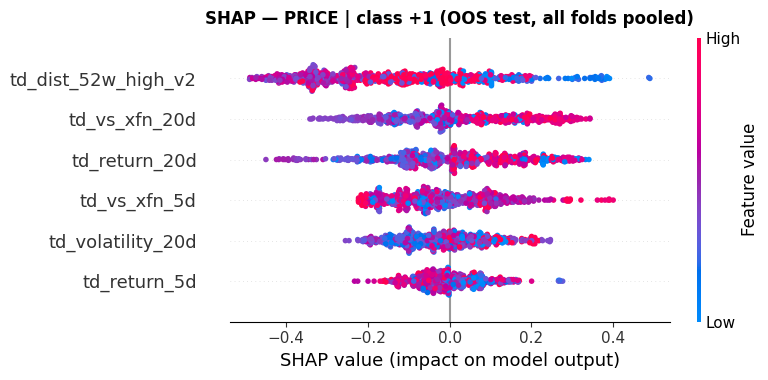

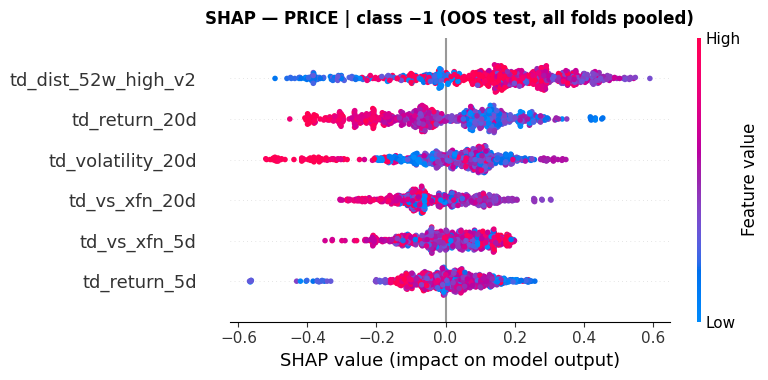

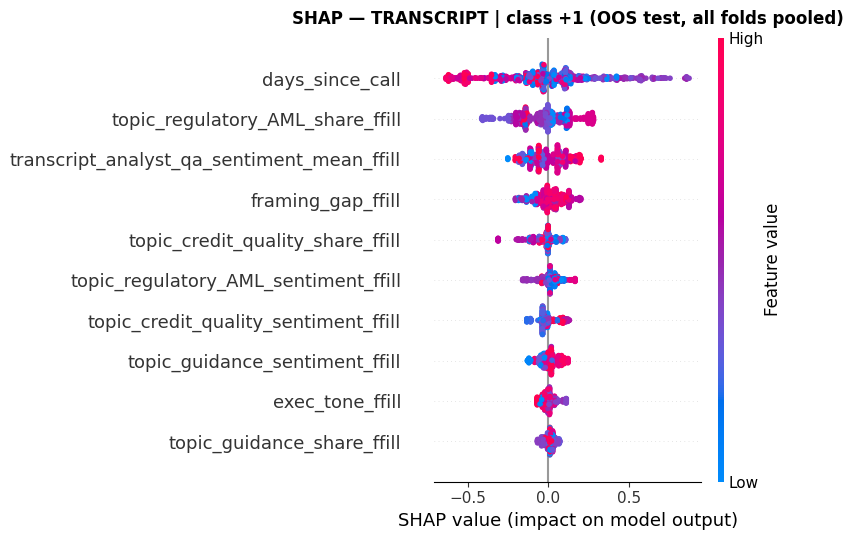

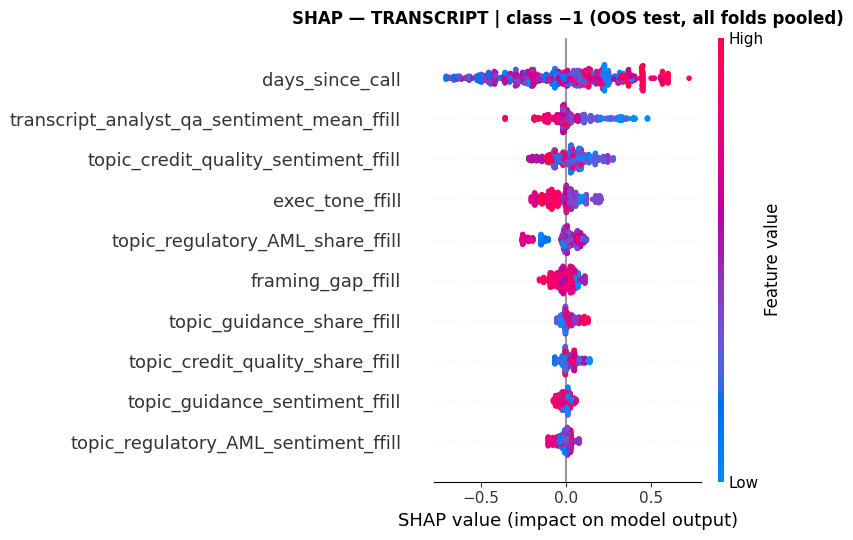

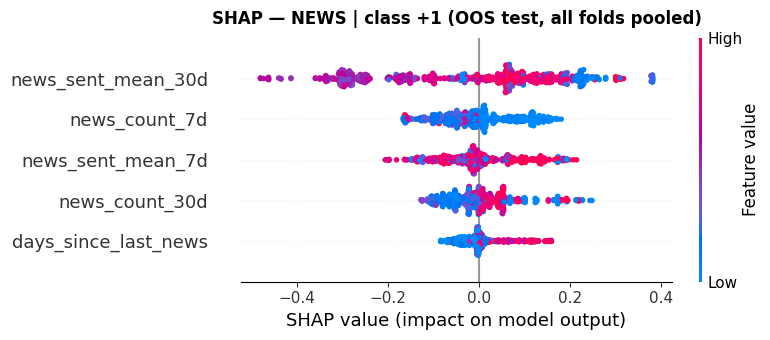

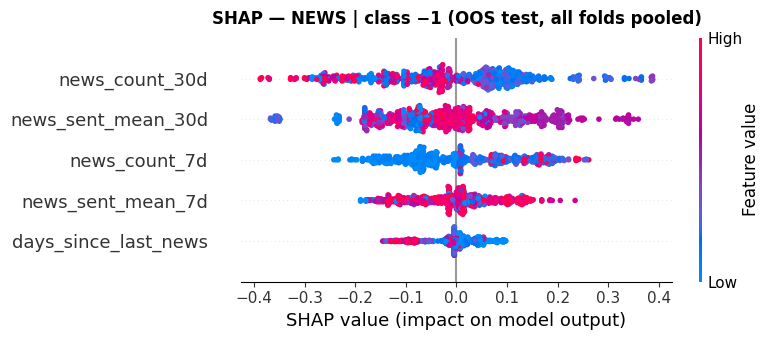

In [9]:
for model_name in model_names:
    features = ALL_FEATURES[model_name]
    x_parts, sv_up_parts, sv_dn_parts = [], [], []

    for fi, clf in enumerate(fold_clfs[model_name]):
        x_te = fold_x_te_list[model_name][fi]
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(x_te)
        if isinstance(sv, list):
            sv_up = sv[2]
            sv_dn = sv[0]
        else:
            sv_arr = np.asarray(sv)
            sv_up = sv_arr[:, :, 2] if sv_arr.ndim == 3 else sv_arr
            sv_dn = sv_arr[:, :, 0] if sv_arr.ndim == 3 else sv_arr

        x_parts.append(x_te)
        sv_up_parts.append(sv_up)
        sv_dn_parts.append(sv_dn)

    x_all = pd.concat(x_parts, ignore_index=True)
    sv_up = np.vstack(sv_up_parts)
    sv_dn = np.vstack(sv_dn_parts)

    fig_h = max(4.5, len(features) * 0.42)
    plt.figure(figsize=(8, fig_h))
    shap.summary_plot(sv_up, x_all, plot_type='dot', show=False, max_display=len(features))
    plt.title(f'SHAP — {model_name.upper()} | class +1 (OOS test, all folds pooled)',
              fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(8, fig_h))
    shap.summary_plot(sv_dn, x_all, plot_type='dot', show=False, max_display=len(features))
    plt.title(f'SHAP — {model_name.upper()} | class −1 (OOS test, all folds pooled)',
              fontweight='bold', pad=10)
    plt.tight_layout()
    plt.show()

## 9. Walk-Forward SHAP Importance (Mean |SHAP| per Fold)

Per-fold test SHAP averaged across folds — side-by-side bars for +1 (steelblue) and −1 (tomato).

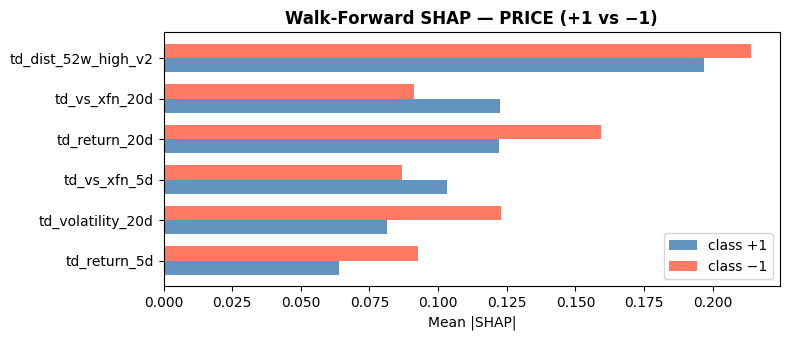


[price] Mean |SHAP| (+1):


,mean_abs_shap_+1
td_dist_52w_high_v2,0.1969
td_vs_xfn_20d,0.1226
td_return_20d,0.1221
td_vs_xfn_5d,0.1033
td_volatility_20d,0.0813
td_return_5d,0.0638


[price] Mean |SHAP| (−1):


,mean_abs_shap_-1
td_dist_52w_high_v2,0.2138
td_return_20d,0.1594
td_volatility_20d,0.1229
td_return_5d,0.0928
td_vs_xfn_20d,0.0913
td_vs_xfn_5d,0.0867


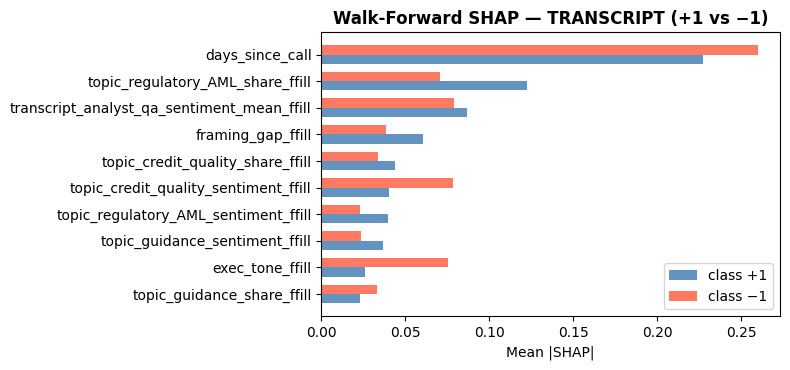


[transcript] Mean |SHAP| (+1):


,mean_abs_shap_+1
days_since_call,0.2270
topic_regulatory_AML_share_ffill,0.1226
transcript_analyst_qa_sentiment_mean_ffill,0.0866
framing_gap_ffill,0.0604
topic_credit_quality_share_ffill,0.0436
topic_credit_quality_sentiment_ffill,0.0402
topic_regulatory_AML_sentiment_ffill,0.0398
topic_guidance_sentiment_ffill,0.0367
exec_tone_ffill,0.0261
topic_guidance_share_ffill,0.0228


[transcript] Mean |SHAP| (−1):


,mean_abs_shap_-1
days_since_call,0.2601
transcript_analyst_qa_sentiment_mean_ffill,0.0788
topic_credit_quality_sentiment_ffill,0.0784
exec_tone_ffill,0.0753
topic_regulatory_AML_share_ffill,0.0709
framing_gap_ffill,0.0384
topic_credit_quality_share_ffill,0.0338
topic_guidance_share_ffill,0.0331
topic_guidance_sentiment_ffill,0.0233
topic_regulatory_AML_sentiment_ffill,0.0230


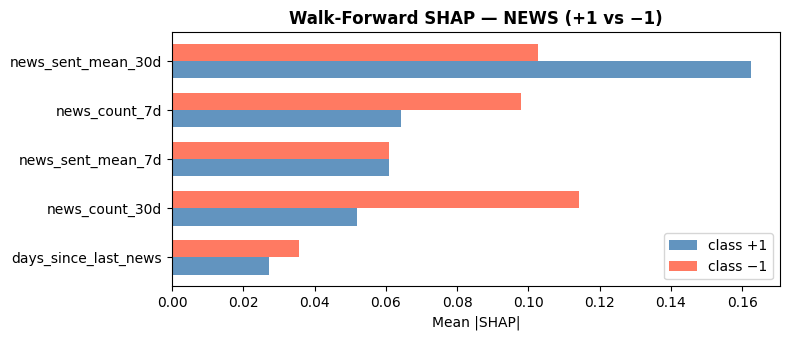


[news] Mean |SHAP| (+1):


,mean_abs_shap_+1
news_sent_mean_30d,0.1625
news_count_7d,0.0642
news_sent_mean_7d,0.0607
news_count_30d,0.0520
days_since_last_news,0.0273


[news] Mean |SHAP| (−1):


,mean_abs_shap_-1
news_count_30d,0.1140
news_sent_mean_30d,0.1028
news_count_7d,0.0979
news_sent_mean_7d,0.0609
days_since_last_news,0.0356


In [10]:
for model_name in model_names:
    features = ALL_FEATURES[model_name]
    rows_up, rows_dn = [], []

    for fi, clf in enumerate(fold_clfs[model_name]):
        x_te = fold_x_te_list[model_name][fi]
        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(x_te)
        if isinstance(sv, list):
            sv_up = sv[2]
            sv_dn = sv[0]
        else:
            sv_arr = np.asarray(sv)
            sv_up = sv_arr[:, :, 2] if sv_arr.ndim == 3 else sv_arr
            sv_dn = sv_arr[:, :, 0] if sv_arr.ndim == 3 else sv_arr

        rows_up.append(pd.Series(np.abs(sv_up).mean(axis=0), index=features))
        rows_dn.append(pd.Series(np.abs(sv_dn).mean(axis=0), index=features))

    mean_up = pd.DataFrame(rows_up).mean().sort_values(ascending=True)
    mean_dn = pd.DataFrame(rows_dn).mean().reindex(mean_up.index)

    y_pos = np.arange(len(mean_up))
    h = 0.35
    plt.figure(figsize=(8, max(3.5, len(features) * 0.38)))
    plt.barh(y_pos - h / 2, mean_up.values, height=h, label='class +1', color='steelblue', alpha=0.85)
    plt.barh(y_pos + h / 2, mean_dn.values, height=h, label='class −1', color='tomato', alpha=0.85)
    plt.yticks(y_pos, mean_up.index)
    plt.xlabel('Mean |SHAP|')
    plt.title(f'Walk-Forward SHAP — {model_name.upper()} (+1 vs −1)', fontweight='bold')
    plt.legend(loc='lower right')
    plt.tight_layout()
    plt.show()

    print(f'\n[{model_name}] Mean |SHAP| (+1):')
    display(mean_up.sort_values(ascending=False).round(4).to_frame('mean_abs_shap_+1'))
    print(f'[{model_name}] Mean |SHAP| (−1):')
    display(mean_dn.sort_values(ascending=False).round(4).to_frame('mean_abs_shap_-1'))

## 10. Per-Fold SHAP Breakdown — All Models

Top-3 features by mean |SHAP| for each model, each fold, for class +1 and class −1.
Useful for understanding which signals drove (or misled) predictions in each specific quarter.

In [11]:
fold_da_map = {r['fold']: r['directional_accuracy'] for r in df_hard.reset_index().to_dict('records')}

for model_name in model_names:
    features = ALL_FEATURES[model_name]
    print(f'\n{'='*70}')
    print(f'MODEL: {model_name.upper()}')
    print(f'{'='*70}')
    print(f'{"Fold":<6} {"Period":<24} {"DA":>5}  Top-3 +1                           Top-3 -1')
    print('-'*110)

    for fi, (fold_id, tr_s, tr_e, te_s, te_e) in enumerate(FOLDS):
        if fi >= len(fold_clfs[model_name]):
            break
        clf = fold_clfs[model_name][fi]
        x_te = fold_x_te_list[model_name][fi]

        explainer = shap.TreeExplainer(clf)
        sv = explainer.shap_values(x_te)
        if isinstance(sv, list):
            sv_up = np.abs(sv[2]).mean(axis=0)
            sv_dn = np.abs(sv[0]).mean(axis=0)
        else:
            sv_arr = np.asarray(sv)
            sv_up = np.abs(sv_arr[:, :, 2]).mean(axis=0)
            sv_dn = np.abs(sv_arr[:, :, 0]).mean(axis=0)

        top3_up = [(features[j], round(float(sv_up[j]), 3)) for j in np.argsort(sv_up)[::-1][:3]]
        top3_dn = [(features[j], round(float(sv_dn[j]), 3)) for j in np.argsort(sv_dn)[::-1][:3]]

        period = f'{te_s} → {te_e}'
        da = fold_da_map.get(fold_id, float('nan'))
        up_str = ', '.join(f'{f}({v})' for f, v in top3_up)
        dn_str = ', '.join(f'{f}({v})' for f, v in top3_dn)
        print(f'{fold_id:<6} {period:<24} {da:>5.3f}  {up_str}')
        print(f'{"":<6} {"":<24} {"":<5}  → {dn_str}')
        print()


MODEL: PRICE
Fold   Period                      DA  Top-3 +1                           Top-3 -1
--------------------------------------------------------------------------------------------------------------


1      2023-03-08 → 2023-06-06  0.361  td_return_20d(0.182), td_vs_xfn_20d(0.123), td_dist_52w_high_v2(0.087)
                                       → td_vs_xfn_5d(0.146), td_return_20d(0.121), td_vs_xfn_20d(0.096)

2      2023-06-07 → 2023-09-06  0.694  td_dist_52w_high_v2(0.259), td_vs_xfn_20d(0.13), td_volatility_20d(0.107)
                                       → td_dist_52w_high_v2(0.22), td_return_20d(0.192), td_vs_xfn_20d(0.106)

3      2023-09-07 → 2023-12-05  0.538  td_dist_52w_high_v2(0.276), td_return_20d(0.148), td_vs_xfn_5d(0.135)
                                       → td_dist_52w_high_v2(0.334), td_return_20d(0.159), td_return_5d(0.108)

4      2023-12-06 → 2024-03-07  0.657  td_dist_52w_high_v2(0.265), td_vs_xfn_5d(0.149), td_volatility_20d(0.108)
                                       → td_dist_52w_high_v2(0.247), td_vs_xfn_5d(0.131), td_volatility_20d(0.122)

5      2024-03-08 → 2024-06-06  0.572  td_dist_52w_high_v2(0.397), td_vs_xfn_5d(0.131), td_vs_xfn_20d(0.125)


6      2024-06-07 → 2024-09-06  0.594  td_dist_52w_high_v2(0.256), td_vs_xfn_20d(0.157), td_vs_xfn_5d(0.086)
                                       → td_dist_52w_high_v2(0.275), td_volatility_20d(0.134), td_return_5d(0.085)



7      2024-09-09 → 2024-12-05  0.686  td_dist_52w_high_v2(0.296), td_vs_xfn_20d(0.13), td_volatility_20d(0.105)
                                       → td_dist_52w_high_v2(0.359), td_volatility_20d(0.174), td_return_20d(0.128)



8      2024-12-06 → 2025-03-10  0.388  td_dist_52w_high_v2(0.254), td_vs_xfn_5d(0.151), td_return_20d(0.146)
                                       → td_dist_52w_high_v2(0.297), td_volatility_20d(0.242), td_return_20d(0.211)

9      2025-03-11 → 2025-06-09  0.459  td_vs_xfn_20d(0.212), td_dist_52w_high_v2(0.194), td_volatility_20d(0.102)
                                       → td_vs_xfn_20d(0.206), td_dist_52w_high_v2(0.163), td_return_20d(0.152)

10     2025-06-10 → 2025-09-09  0.663  td_return_20d(0.18), td_vs_xfn_20d(0.178), td_volatility_20d(0.085)
                                       → td_return_20d(0.172), td_dist_52w_high_v2(0.168), td_vs_xfn_20d(0.115)

11     2025-09-10 → 2025-12-08  0.457  td_vs_xfn_20d(0.181), td_vs_xfn_5d(0.164), td_return_20d(0.148)
                                       → td_return_20d(0.187), td_vs_xfn_20d(0.123), td_volatility_20d(0.114)

12     2025-12-09 → 2026-03-11  0.691  td_return_20d(0.257), td_dist_52w_high_v2(0.103), td_vs_xfn_5d(0.101)
    

...

4      2023-12-06 → 2024-03-07  0.657  days_since_call(0.159), transcript_analyst_qa_sentiment_mean_ffill(0.134), framing_gap_ffill(0.099)
                                       → transcript_analyst_qa_sentiment_mean_ffill(0.318), days_since_call(0.209), framing_gap_ffill(0.052)



5      2024-03-08 → 2024-06-06  0.572  topic_regulatory_AML_share_ffill(0.307), transcript_analyst_qa_sentiment_mean_ffill(0.16), days_since_call(0.098)
                                       → topic_credit_quality_sentiment_ffill(0.205), days_since_call(0.155), transcript_analyst_qa_sentiment_mean_ffill(0.13)

6      2024-06-07 → 2024-09-06  0.594  days_since_call(0.204), topic_regulatory_AML_share_ffill(0.115), topic_guidance_sentiment_ffill(0.096)
                                       → days_since_call(0.274), transcript_analyst_qa_sentiment_mean_ffill(0.085), topic_credit_quality_sentiment_ffill(0.074)

7      2024-09-09 → 2024-12-05  0.686  days_since_call(0.403), topic_regulatory_AML_share_ffill(0.179), framing_gap_ffill(0.058)
                                       → days_since_call(0.314), exec_tone_ffill(0.169), topic_credit_quality_sentiment_ffill(0.095)

8      2024-12-06 → 2025-03-10  0.388  days_since_call(0.247), topic_regulatory_AML_share_ffill(0.144), framing_gap_ffill

3      2023-09-07 → 2023-12-05  0.538  news_sent_mean_7d(0.14), news_sent_mean_30d(0.12), news_count_30d(0.088)
                                       → news_sent_mean_7d(0.134), news_count_30d(0.133), news_count_7d(0.073)

4      2023-12-06 → 2024-03-07  0.657  news_sent_mean_30d(0.229), news_sent_mean_7d(0.086), news_count_30d(0.054)
                                       → news_sent_mean_30d(0.144), news_count_7d(0.102), news_sent_mean_7d(0.096)

5      2024-03-08 → 2024-06-06  0.572  news_sent_mean_30d(0.212), news_sent_mean_7d(0.089), news_count_7d(0.068)
                                       → news_count_7d(0.168), news_sent_mean_30d(0.126), news_sent_mean_7d(0.058)



6      2024-06-07 → 2024-09-06  0.594  news_sent_mean_30d(0.258), news_count_7d(0.081), news_sent_mean_7d(0.054)
                                       → news_sent_mean_30d(0.152), news_count_7d(0.139), news_count_30d(0.054)

7      2024-09-09 → 2024-12-05  0.686  news_sent_mean_30d(0.235), news_count_7d(0.102), days_since_last_news(0.034)
                                       → news_sent_mean_30d(0.182), news_count_7d(0.137), news_count_30d(0.053)

8      2024-12-06 → 2025-03-10  0.388  news_count_7d(0.138), news_sent_mean_30d(0.122), days_since_last_news(0.065)
                                       → news_sent_mean_30d(0.118), news_count_7d(0.115), days_since_last_news(0.085)

9      2025-03-11 → 2025-06-09  0.459  news_sent_mean_30d(0.168), news_count_7d(0.091), days_since_last_news(0.067)
                                       → news_count_30d(0.144), news_count_7d(0.106), news_sent_mean_30d(0.103)



10     2025-06-10 → 2025-09-09  0.663  news_sent_mean_30d(0.229), days_since_last_news(0.08), news_count_30d(0.054)
                                       → news_count_30d(0.173), news_sent_mean_30d(0.141), days_since_last_news(0.064)

11     2025-09-10 → 2025-12-08  0.457  news_sent_mean_30d(0.239), news_sent_mean_7d(0.059), news_count_7d(0.058)
                                       → news_sent_mean_7d(0.112), news_count_30d(0.109), news_sent_mean_30d(0.104)

12     2025-12-09 → 2026-03-11  0.691  news_sent_mean_30d(0.116), news_count_7d(0.08), news_count_30d(0.07)
                                       → news_count_30d(0.151), news_sent_mean_7d(0.126), news_count_7d(0.072)

13     2026-03-12 → 2026-04-09  0.600  news_count_7d(0.116), news_count_30d(0.083), news_sent_mean_7d(0.066)
                                       → news_count_7d(0.177), news_count_30d(0.1), news_sent_mean_7d(0.068)



## 11. Fold 1 & Fold 8 — Per-Direction SHAP Beeswarm Plots

For each of the two worst-performing folds, the plots below show SHAP beeswarm distributions per model and per prediction direction (+1 outperform / −1 underperform).  
Each dot is one test-day observation. **Red = high feature value, Blue = low feature value.** Dots to the right of zero pushed that class prediction up; dots to the left pushed it down.  
These plots confirm which signals were driving predictions in each fold and in which direction.

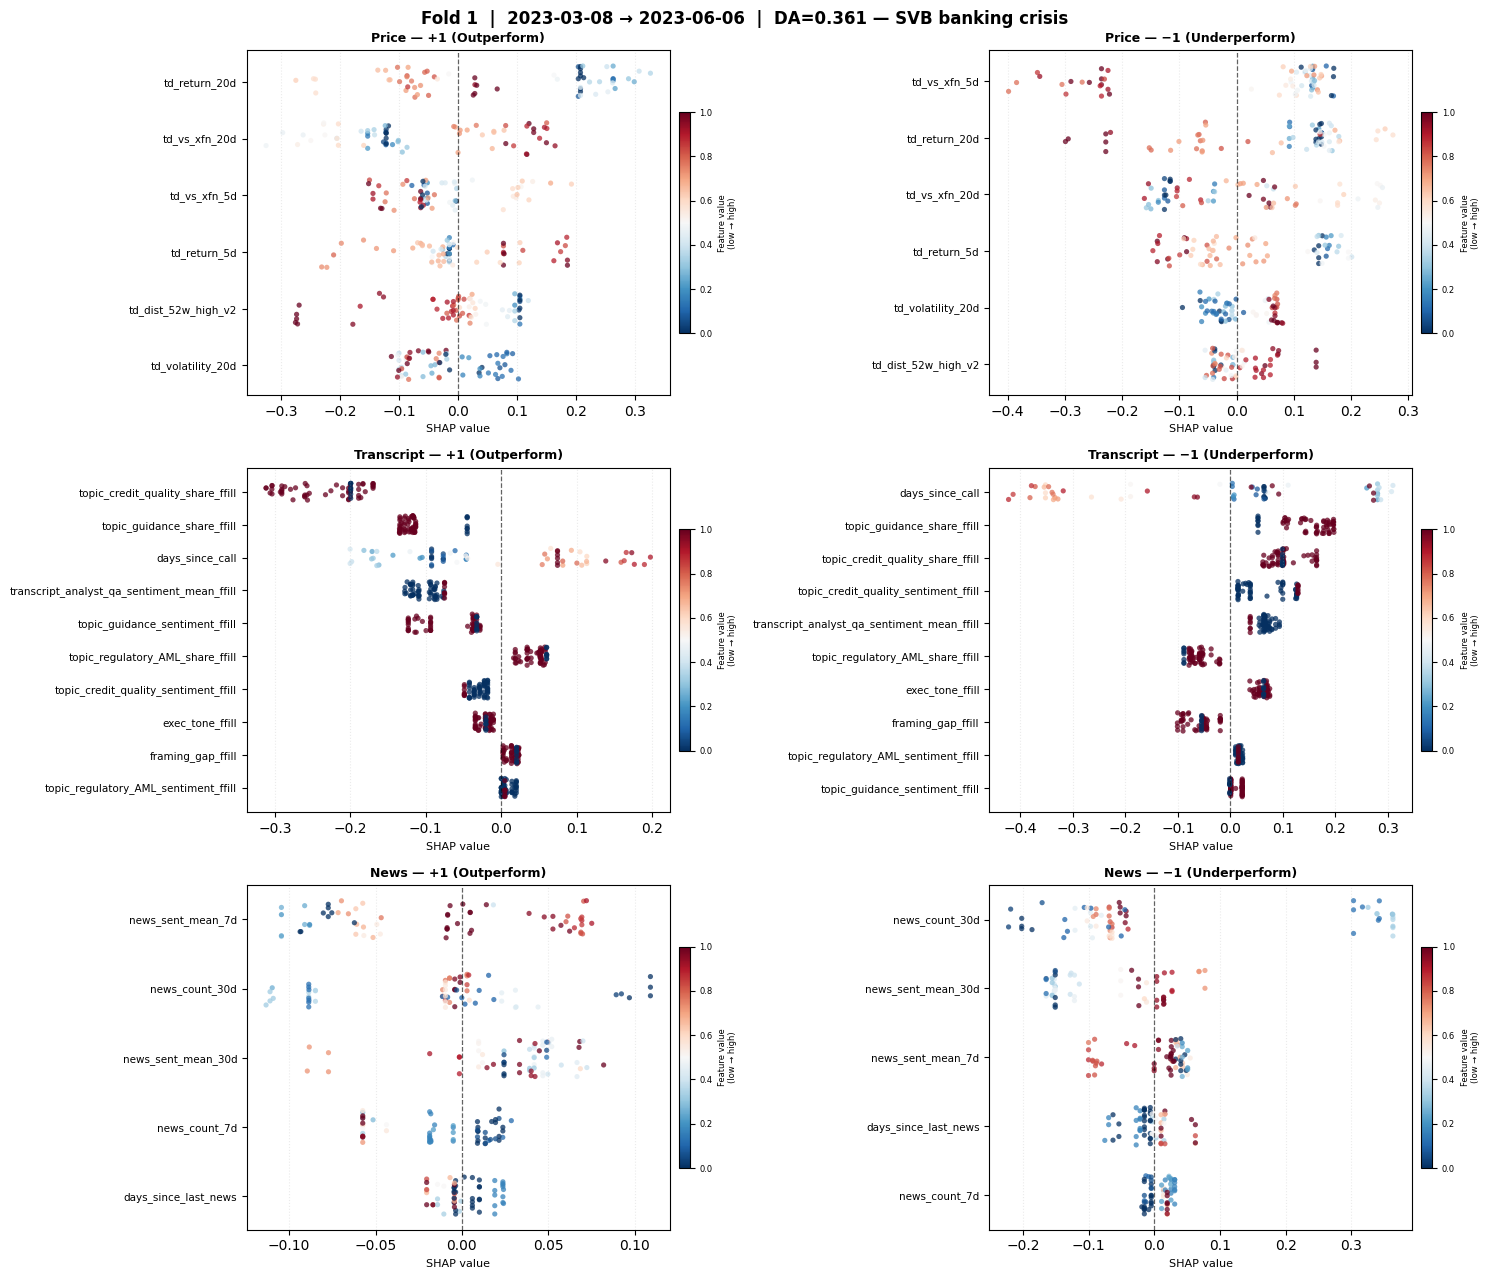

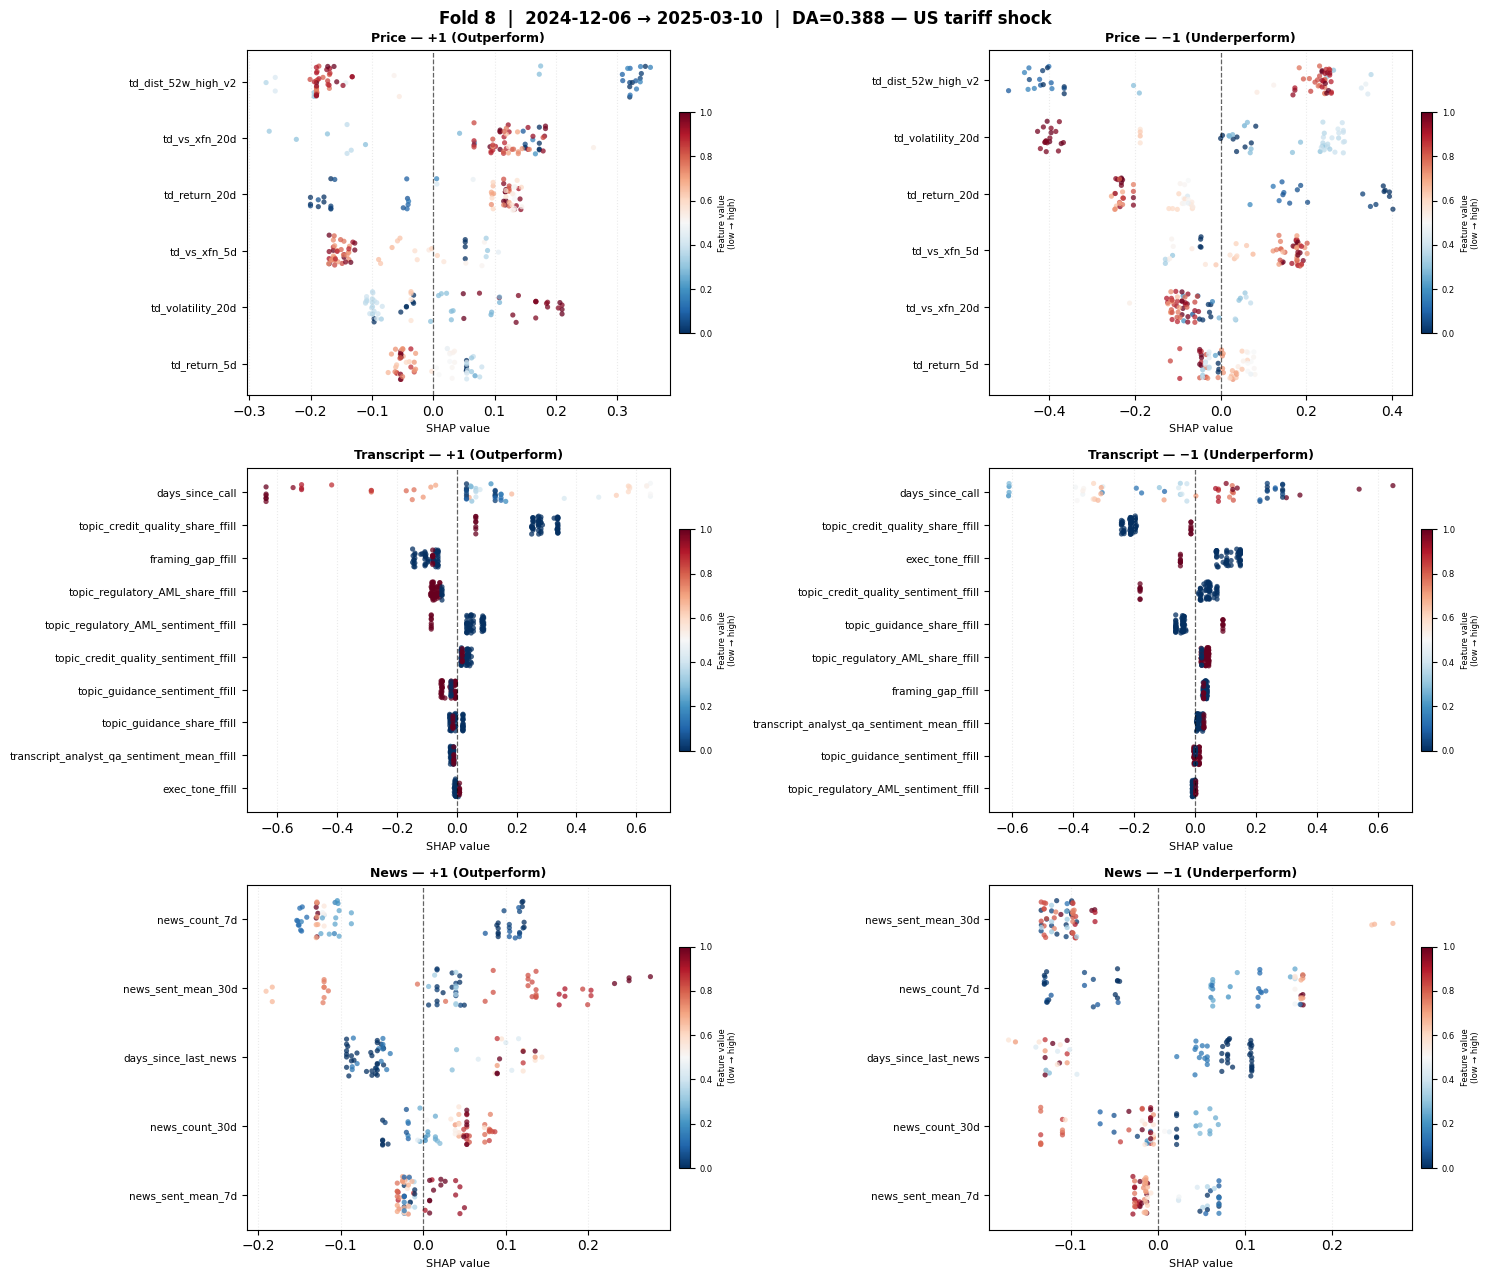

In [12]:
# Fold 1 & 8 — Per-Direction SHAP Summary Plots
# For each fold: 3 models × 2 directions (beeswarm, coloured by feature value)

import io, base64
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import shap

FOLDS_OF_INTEREST = {
    1: ('2021-02-25','2023-03-07','2023-03-08','2023-06-06','DA=0.361 — SVB banking crisis'),
    8: ('2022-12-02','2024-12-05','2024-12-06','2025-03-10','DA=0.388 — US tariff shock'),
}
MAX_FEAT = 10
CLS_PAIRS = [(2, '+1 (Outperform)'), (0, '\u22121 (Underperform)')]

for fold_id, (tr_s, tr_e, te_s, te_e, label) in FOLDS_OF_INTEREST.items():
    train_df = df[(df['date']>=tr_s)&(df['date']<=tr_e)].copy()
    test_df  = df[(df['date']>=te_s)&(df['date']<=te_e)].copy()
    n_test = len(test_df)
    y_tr = np.where(train_df[TARGET].values>THRESHOLD, 2,
                    np.where(train_df[TARGET].values<-THRESHOLD, 0, 1))
    fig, axes = plt.subplots(3, 2, figsize=(15, 13))
    fig.suptitle(f'Fold {fold_id}  |  {te_s} \u2192 {te_e}  |  {label}',
                 fontsize=12, fontweight='bold')
    for row, model_name in enumerate(model_names):
        feats = ALL_FEATURES[model_name]
        avail = [f for f in feats if f in df.columns]
        X_tr = train_df[avail].fillna(0).values
        X_te = test_df[avail].fillna(0).values
        clf, *_ = fit_xgb(train_df, test_df, avail, BEST_PARAMS[model_name])
        explainer = shap.TreeExplainer(clf)
        raw = explainer.shap_values(X_te)
        get_sv = (lambda ci: raw[:,:,ci]) if (isinstance(raw, np.ndarray) and raw.ndim==3) else (lambda ci: np.array(raw[ci]))
        for col, (cls_idx, cls_label) in enumerate(CLS_PAIRS):
            ax = axes[row][col]
            sv = get_sv(cls_idx)
            mean_abs = np.abs(sv).mean(axis=0)
            top_idx = np.argsort(mean_abs)[::-1][:MAX_FEAT]
            sv_top = sv[:, top_idx]; fv_top = X_te[:, top_idx]
            feat_names_top = [avail[i] for i in top_idx]
            n_shown = len(top_idx)
            rng = np.random.default_rng(fold_id*100 + row*10 + col)
            for fi in range(n_shown):
                y_pos = n_shown - 1 - fi
                sv_col = sv_top[:, fi]; fv_col = fv_top[:, fi]
                vmin, vmax = np.nanpercentile(fv_col,5), np.nanpercentile(fv_col,95)
                if vmax==vmin: vmax += 1e-9
                c_norm = np.clip((fv_col-vmin)/(vmax-vmin), 0, 1)
                jitter = rng.uniform(-0.28, 0.28, size=n_test)
                ax.scatter(sv_col, np.full(n_test,y_pos)+jitter,
                           c=c_norm, cmap='RdBu_r', vmin=0, vmax=1, s=14, alpha=0.75, linewidths=0)
            ax.axvline(0, color='black', lw=0.9, ls='--', alpha=0.6)
            ax.set_yticks(range(n_shown)); ax.set_yticklabels(feat_names_top[::-1], fontsize=7.5)
            ax.set_xlabel('SHAP value', fontsize=8)
            ax.set_title(f'{model_name.capitalize()} \u2014 {cls_label}', fontsize=9, fontweight='bold')
            ax.grid(axis='x', alpha=0.25, ls=':')
            sm = plt.cm.ScalarMappable(cmap='RdBu_r'); sm.set_array([])
            cb = fig.colorbar(sm, ax=ax, fraction=0.025, pad=0.02)
            cb.set_label('Feature value\n(low \u2192 high)', fontsize=6); cb.ax.tick_params(labelsize=6)
    plt.tight_layout(); plt.show()


## 12. Model Governance — Baseline Comparison & Statistical Significance

Compares the ensemble's aggregate directional accuracy against two baselines appropriate for an institutional investor, and quantifies precision with a **95% Wald confidence interval**.

**Majority class**: predict the most frequently occurring training label on every test day. A pension fund model that can't beat naive class-frequency prediction adds no signal.

**Momentum**: predict that TD will continue beating (or lagging) XFN in the same direction as the prior 5-day relative return. This is the most common naïve alternative to a quantitative model in a relative-return context — and the benchmark the archive model card identifies as most relevant for a pension mandate.

**Wald CI**: the range of true underlying accuracy values consistent with the observed data at 95% confidence. If 0.50 (random) falls below the lower bound, the result is statistically distinguishable from chance without needing a separate test.

In [13]:
import numpy as np

# ── 1. Per-fold baseline computation ─────────────────────────────────────────
fold_stats = []   # one dict per fold

for fi, (fold_id, tr_s, tr_e, te_s, te_e) in enumerate(FOLDS):
    if fi >= len(fold_y_cont_list):
        break
    y_cont = fold_y_cont_list[fi]

    # Ensemble DA and n_calls for this fold (from df_hard)
    ens_da  = df_hard.loc[fold_id, 'directional_accuracy']
    n_calls = int(round(df_hard.loc[fold_id, 'test_rows'] *
                        df_hard.loc[fold_id, 'directional_call_rate']))

    # Wald 95% CI for this fold
    se     = np.sqrt(ens_da * (1 - ens_da) / n_calls) if n_calls > 0 else float('nan')
    ci_lo  = ens_da - 1.96 * se
    ci_hi  = ens_da + 1.96 * se
    sig    = '*' if ci_lo > 0.50 else ' '   # * = lower CI bound above random

    # Majority-class baseline
    train_rows   = df[(df['date'] >= pd.Timestamp(tr_s)) &
                      (df['date'] <= pd.Timestamp(tr_e)) & df[TARGET].notna()]
    train_labels = label_3class(train_rows[TARGET].values, threshold=THRESHOLD)
    vals, counts = np.unique(train_labels, return_counts=True)
    maj_cls      = vals[np.argmax(counts)]
    if maj_cls != 0:
        maj_da = float((np.sign(maj_cls) == np.sign(y_cont)).mean())
    else:
        maj_da = float('nan')   # majority is neutral → no directional call

    # Momentum baseline: sign of prior td_vs_xfn_5d
    test_rows  = df[(df['date'] >= pd.Timestamp(te_s)) &
                    (df['date'] <= pd.Timestamp(te_e)) & df[TARGET].notna()]
    signal     = np.sign(test_rows['td_vs_xfn_5d'].fillna(0).values)
    active     = signal != 0
    mom_da     = float((np.sign(signal[active]) == np.sign(y_cont[active])).mean()) \
                 if active.any() else float('nan')

    fold_stats.append(dict(
        fold_id=fold_id, te_s=te_s, te_e=te_e,
        ens_da=ens_da, n_calls=n_calls, ci_lo=ci_lo, ci_hi=ci_hi, sig=sig,
        maj_da=maj_da, mom_da=mom_da,
    ))

# ── 2. Aggregate stats ───────────────────────────────────────────────────────
n_calls_total = sum(s['n_calls'] for s in fold_stats)
da_agg   = df_hard['directional_accuracy'].mean()          # mean-of-fold (matches § 7)
se_agg   = np.sqrt(da_agg * (1 - da_agg) / n_calls_total)
ci_lo_agg, ci_hi_agg = da_agg - 1.96 * se_agg, da_agg + 1.96 * se_agg

# Aggregate baselines (skip folds where majority is neutral)
maj_rows = [(s['maj_da'], len(fold_y_cont_list[i]))
            for i, s in enumerate(fold_stats) if not np.isnan(s['maj_da'])]
maj_da_agg = sum(d * n for d, n in maj_rows) / sum(n for _, n in maj_rows) if maj_rows else float('nan')

mom_total   = sum(s['n_calls'] for s in fold_stats if not np.isnan(s['mom_da']))
mom_da_agg  = np.nanmean([s['mom_da'] for s in fold_stats])

# ── 3. Per-fold table ────────────────────────────────────────────────────────
print("§ 12  Model Governance — Baseline Comparison & Statistical Significance")
print("=" * 80)
print()
print("Per-fold breakdown  (* = lower 95% CI bound > 50.0%)")
print()
print(f"{'Fold':>4}  {'Test period':<24}  {'n':>4}  {'Ensemble DA':>11}  {'95% CI':>16}   {'Majority':>8}  {'Momentum':>8}")
print("-" * 80)
for s in fold_stats:
    ci_str = f"[{s['ci_lo']:.1%}, {s['ci_hi']:.1%}]"
    maj_str = f"{s['maj_da']:.1%}" if not np.isnan(s['maj_da']) else "  n/a "
    mom_str = f"{s['mom_da']:.1%}" if not np.isnan(s['mom_da']) else "  n/a "
    print(f"{s['fold_id']:>4}  {s['te_s']} → {s['te_e']}  {s['n_calls']:>4}  "
          f"{s['ens_da']:>10.1%}{s['sig']}  {ci_str:>16}   {maj_str:>8}  {mom_str:>8}")

# ── 4. Aggregate summary ─────────────────────────────────────────────────────
print("-" * 80)
ci_agg_str = f"[{ci_lo_agg:.1%}, {ci_hi_agg:.1%}]"
print(f"{'Agg':>4}  {'(mean of 13 fold DAs)':<24}  {n_calls_total:>4}  "
      f"{da_agg:>10.1%}   {ci_agg_str:>16}   {maj_da_agg:>8.1%}  {mom_da_agg:>8.1%}")
print()
print(f"  Lift vs majority class:  {da_agg - maj_da_agg:+.1%}pp")
print(f"  Lift vs momentum:        {da_agg - mom_da_agg:+.1%}pp")
print(f"  Aggregate CI lower bound ({ci_lo_agg:.1%}) > 50.0% — statistically")
print(f"  distinguishable from a coin flip at 95% confidence.")
print()
print("  Note: RF baselines (rf_option_a DA=41.4%, rf_option_c DA=49.3%) excluded —")
print("  single train/test split, 137 features, non-walk-forward test window.")

§ 12  Model Governance — Baseline Comparison & Statistical Significance

Per-fold breakdown  (* = lower 95% CI bound > 50.0%)

Fold  Test period                  n  Ensemble DA            95% CI   Majority  Momentum
--------------------------------------------------------------------------------
   1  2023-03-08 → 2023-06-06    61       36.1%     [24.1%, 48.2%]      47.6%     42.9%
   2  2023-06-07 → 2023-09-06    60       69.4%*    [57.8%, 81.1%]      71.4%     60.3%
   3  2023-09-07 → 2023-12-05    63       53.8%     [41.5%, 66.2%]      47.6%     54.0%
   4  2023-12-06 → 2024-03-07    61       65.7%*    [53.8%, 77.6%]      31.7%     49.2%
   5  2024-03-08 → 2024-06-06    63       57.2%     [45.0%, 69.4%]      52.4%     42.9%
   6  2024-06-07 → 2024-09-06    59       59.4%     [46.9%, 71.9%]      55.6%     42.9%
   7  2024-09-09 → 2024-12-05    63       68.6%*    [57.1%, 80.1%]      69.8%     44.4%
   8  2024-12-06 → 2025-03-10    62       38.8%     [26.7%, 51.0%]      15.9%     63.5%